In [1]:
# Import libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf

In [2]:
# Load data
df = pd.read_parquet("../data/processed/acs_cleaned.parquet")

df = df.rename(columns={
    "Log Income": "Log_Income"
})

df["Age2"] = df["Age"]**2

In [3]:
# Helper function for weighted means
def weighted_mean(x, value_col, weight_col="Individuals Represented"):
    return np.sum(x[value_col] * x[weight_col]) / np.sum(x[weight_col])

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2817128028.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Year", "Education Group"])
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2817128028.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))


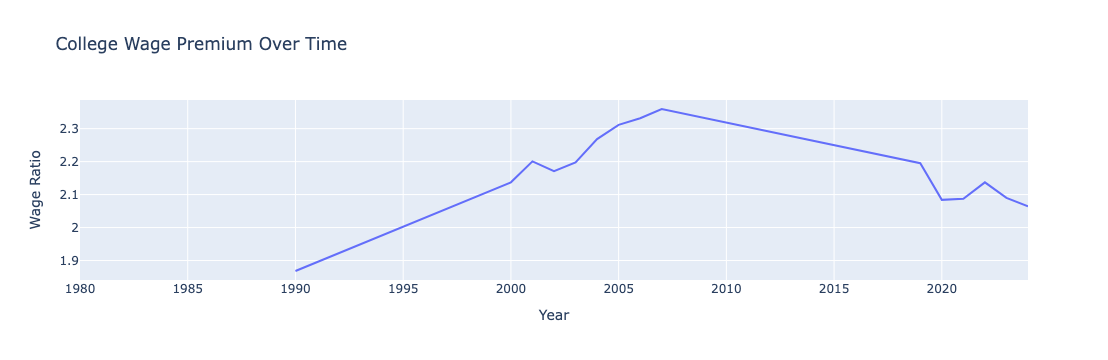

In [4]:
# College wage premium over time
premium = (
    df.groupby(["Year", "Education Group"])
    .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))
    .reset_index(name="Income")
)

premium_wide = premium.pivot(index="Year", columns="Education Group", values="Income").reset_index()
premium_wide["College Premium"] = premium_wide["Bachelor's"] / premium_wide["HS or Less"]

fig = px.line(
    premium_wide,
    x="Year",
    y="College Premium",
    title="College Wage Premium Over Time",
    labels={"College Premium": "Wage Ratio"}
)

fig.update_traces(mode="lines")
fig.show()

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/4057810123.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/4057810123.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



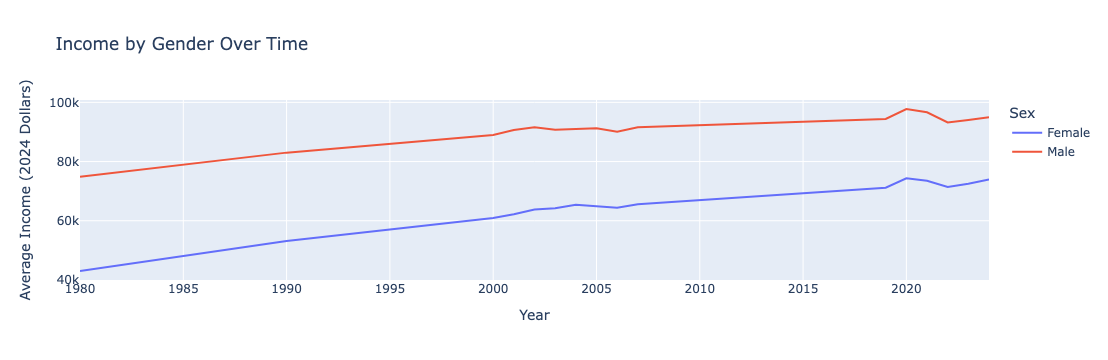

In [5]:
# Wage trends by gender
income_gender = (
    df.groupby(["Year", "Sex"])
    .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))
    .reset_index(name="Income")
)

fig = px.line(
    income_gender,
    x="Year",
    y="Income",
    color="Sex",
    title="Income by Gender Over Time",
    labels={"Income": "Average Income (2024 Dollars)"}
)

fig.show()

In [6]:
# Wage trends by demographic group
income_demo = (
    df.groupby(["Year", "Demographic"])
    .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))
    .reset_index(name="Income")
)

fig = px.line(
    income_demo,
    x="Year",
    y="Income",
    color="Demographic",
    title="Income by Demographic Group Over Time",
    labels={"Income": "Average Income (2024 Dollars)"}
)

fig.show()

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2509344264.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2509344264.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [7]:
# State chloropleth map
state_income = (
    df.groupby("State")
    .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))
    .reset_index(name="Income")
)

state_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY"
}

state_income["abbr"] = state_income["State"].map(state_abbrev)

fig = px.choropleth(
    state_income,
    locations="abbr",
    locationmode="USA-states",
    color="Income",
    hover_name="State",
    scope="usa",
    title="Average Income by State",
    color_continuous_scale="Blues"
)

fig.show()

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/481014136.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/481014136.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [8]:
# Major earnings bar chart
major_income = (
    df.dropna(subset=["Major"])
    .groupby("Major")
    .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))
    .reset_index(name="Income")
    .sort_values("Income", ascending=False)
)

top_majors = major_income.head(15)

fig = px.bar(
    top_majors,
    x="Income",
    y="Major",
    orientation="h",
    title="Top 15 College Majors by Average Income",
    labels={"Income": "Average Income (2024 Dollars)"}
)

fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2868302555.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2868302555.py:5: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [9]:
# Wage map over time
state_year_income = (
    df.groupby(["Year", "State"])
    .apply(lambda x: weighted_mean(x, "Income (2024 Dollars)"))
    .reset_index(name="Income")
)

state_year_income["abbr"] = state_year_income["State"].map(state_abbrev)

fig = px.choropleth(
    state_year_income,
    locations="abbr",
    locationmode="USA-states",
    color="Income",
    hover_name="State",
    scope="usa",
    animation_frame="Year",
    title="Average Income by State Over Time",
    color_continuous_scale="Blues"
)

fig.show()

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2043363680.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_29110/2043363680.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [10]:
# Predicted Age-Earnings Curve by Education
df_model = df.sample(500000, random_state = 123)

model5 = smf.wls(
    """Log_Income ~ 
    C(Q('Education Group')) +
    Age + Age2 +
    C(Sex) +
    C(Demographic) +
    C(State) +
    C(Year)
    """,
    data=df_model,
    weights=df_model["Individuals Represented"]
).fit()

ages = np.arange(25, 65)
edu_groups = ["HS or Less", "Some College", "Bachelor's", "Masters or Doctorate"]

pred_list = []

for edu in edu_groups:
    temp = pd.DataFrame({
        "Age": ages,
        "Age2": ages**2,
        "Education Group": edu,
        "Sex": "Male",
        "Demographic": "White",
        "State": "Texas",
        "Year": 2024
    })
    temp["Predicted Income"] = np.exp(model5.predict(temp))
    pred_list.append(temp)

pred_plot = pd.concat(pred_list, ignore_index=True)

fig = px.line(
    pred_plot,
    x="Age",
    y="Predicted Income",
    color="Education Group",
    title="Predicted Age-Earnings Profiles by Education",
    labels={"Predicted Income": "Predicted Income (2024 Dollars)"}
)

fig.show()